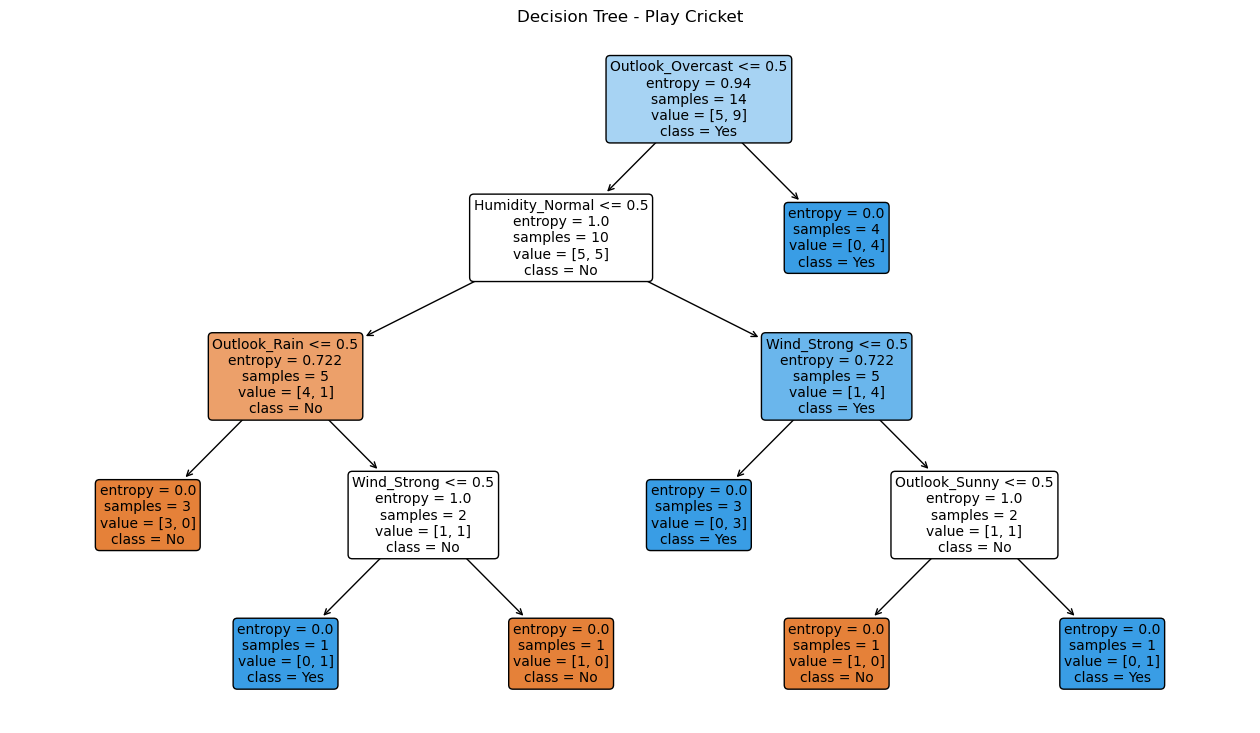

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = {
    'Outlook': [
        'Sunny', 'Sunny', 'Overcast', 'Rain',
        'Rain', 'Rain', 'Overcast', 'Sunny',
        'Sunny', 'Rain', 'Sunny', 'Overcast',
        'Overcast', 'Rain'
    ],
    'Temperature': [
        'Hot', 'Hot', 'Hot', 'Mild',
        'Cool', 'Cool', 'Cool', 'Mild',
        'Cool', 'Mild', 'Mild', 'Mild',
        'Hot', 'Mild'
    ],
    'Humidity': [
        'High', 'High', 'High', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'Normal', 'Normal', 'High',
        'Normal', 'High'
    ],
    'Wind': [
        'Weak', 'Strong', 'Weak', 'Weak',
        'Weak', 'Strong', 'Strong', 'Weak',
        'Weak', 'Weak', 'Strong', 'Strong',
        'Weak', 'Strong'
    ],
    'Play_Cricket': [
        'No', 'No', 'Yes', 'Yes',
        'Yes', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No'
    ]
}

df = pd.DataFrame(data)

X = df.drop('Play_Cricket', axis=1)
y = df['Play_Cricket']

X = pd.get_dummies(X)

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

model.fit(X, y)

plt.figure(figsize=(16, 9))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Play Cricket")
plt.show()


Dataset:
    Day   Outlook Temperature Humidity    Wind Play Cricket
0     1     Sunny         Hot     High    Weak           No
1     2     Sunny         Hot     High  Strong           No
2     3  Overcast         Hot     High    Weak          Yes
3     4      Rain        Mild     High    Weak          Yes
4     5      Rain        Cool   Normal    Weak          Yes
5     6      Rain        Cool   Normal  Strong           No
6     7  Overcast        Cool   Normal  Strong          Yes
7     8     Sunny        Mild     High    Weak           No
8     9     Sunny        Cool   Normal    Weak          Yes
9    10      Rain        Mild   Normal    Weak          Yes
10   11     Sunny        Mild   Normal  Strong          Yes
11   12  Overcast        Mild     High  Strong          Yes
12   13  Overcast         Hot   Normal    Weak          Yes
13   14      Rain        Mild     High  Strong           No

Entropy of Target:
0.9402859586706311

Information Gain:
Outlook : 0.24674981977443933
Tem

Enter Outlook (Sunny/Overcast/Rain):  Sunny
Enter Temperature (Hot/Mild/Cool):  Hot
Enter Humidity (High/Normal):  Normal
Enter Wind (Weak/Strong):  Weak


Prediction: Yes


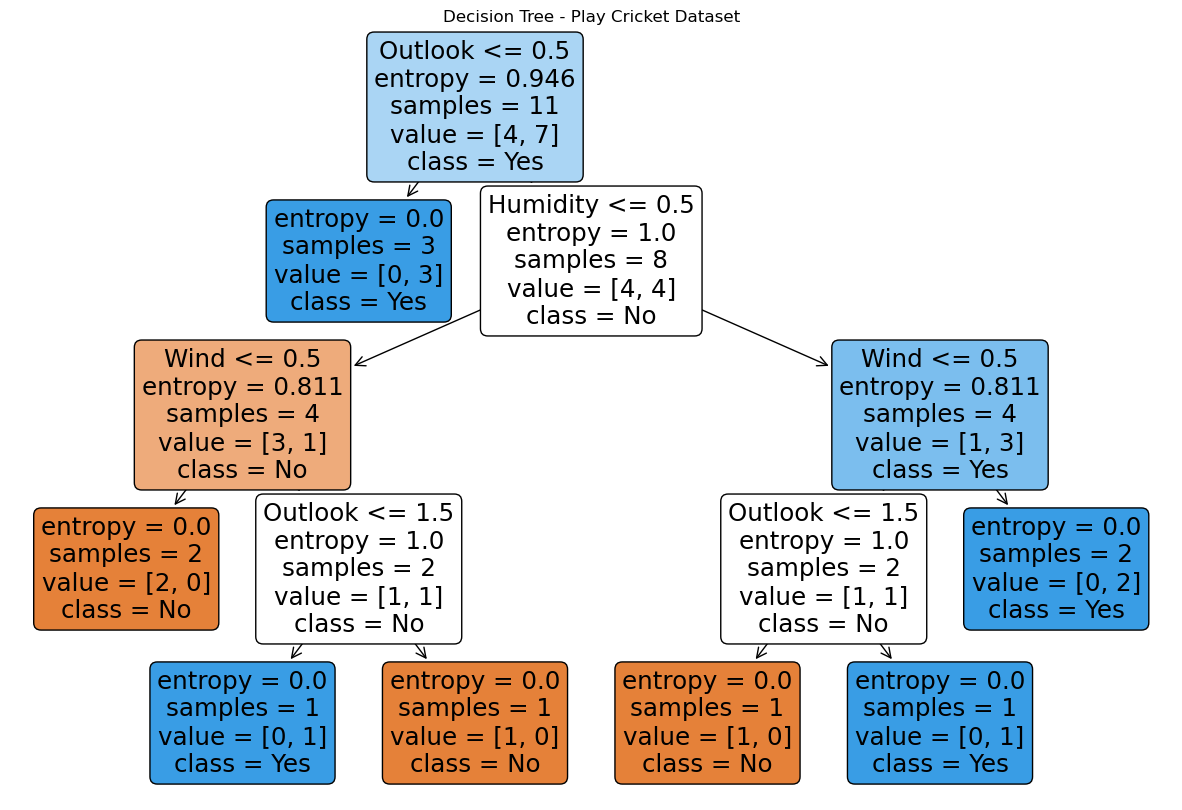

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("play_cricket_dataset.csv")

print("Dataset:")
print(df)

def entropy(data):
    values = data.value_counts()
    total = len(data)
    ent = 0

    for count in values:
        p = count / total
        ent -= p * __import__('math').log2(p)

    return ent

def information_gain(df, attribute, target):
    total_entropy = entropy(df[target])
    weighted_entropy = 0

    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        weighted_entropy += (len(subset) / len(df)) * entropy(subset[target])

    return total_entropy - weighted_entropy

target = "Play Cricket"

attributes = [
    "Outlook",
    "Temperature",
    "Humidity",
    "Wind"
]

print("\nEntropy of Target:")
print(entropy(df[target]))

print("\nInformation Gain:")
for attribute in attributes:
    gain = information_gain(df, attribute, target)
    print(attribute, ":", gain)

best_attribute = max(
    attributes,
    key=lambda attribute: information_gain(df, attribute, target)
)

print("\nSelected Attribute:")
print(best_attribute)

X = df[attributes].copy()
y = df[target]

for column in X.columns:
    X[column] = X[column].astype("category").cat.codes

y = y.astype("category").cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy of Decision Tree:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

outlook = input("Enter Outlook (Sunny/Overcast/Rain): ")
temperature = input("Enter Temperature (Hot/Mild/Cool): ")
humidity = input("Enter Humidity (High/Normal): ")
wind = input("Enter Wind (Weak/Strong): ")

new_flower = pd.DataFrame(
    [[outlook, temperature, humidity, wind]],
    columns=attributes
)

for column in new_flower.columns:
    categories = df[column].astype("category").cat.categories
    new_flower[column] = pd.Categorical(
        new_flower[column],
        categories=categories
    ).codes

prediction = dt_model.predict(new_flower)

if prediction[0] == 1:
    print("Prediction: Yes")
else:
    print("Prediction: No")

plt.figure(figsize=(15, 10))

plot_tree(
    dt_model,
    feature_names=attributes,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - Play Cricket Dataset")
plt.show()